### Propagation model comparison - stochastic models

In [25]:
import commpy.channels as channels
import numpy as np
import matplotlib.pyplot as plt

print(dir(channels))

['MIMOFlatChannel', 'SISOFlatChannel', '_FlatChannel', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'abs', 'absolute', 'array', 'awgn', 'bec', 'bsc', 'cos', 'division', 'einsum', 'exp', 'fromiter', 'hstack', 'identity', 'kron', 'pi', 'print_function', 'randn', 'random', 'sqrt', 'sqrtm', 'standard_normal', 'sum', 'trace', 'zeros']


### Simulation parameters

In [93]:
time_vector = np.linspace(0.001,0.1,100)

freq_ghz = 10
rician_channel = channels.SISOFlatChannel(noise_std=0.05, fading_param=(0.9, 0.19))
mimo_channel = channels.MIMOFlatChannel(
    nb_tx=2,
    nb_rx=2,
    noise_std=0.05,
    fading_param=None
)

### Computations

In [108]:
x = np.sin(2*np.pi*freq_ghz*time_vector)
x_stacked = np.vstack([x, x]).astype(complex)
noise_std = 0.05

x_awgn = channels.awgn(x,10)
x_siso = rician_channel.propagate(x)

H = (np.random.normal(0, np.sqrt(0.5), (2, 2)) +
     1j * np.random.normal(0, np.sqrt(0.5), (2, 2)))

noise = (np.random.normal(0, noise_std, (2, 100)) +
         1j * np.random.normal(0, noise_std, (2, 100)))

x_mimo = np.dot(H, x_stacked) + noise

### Plotting

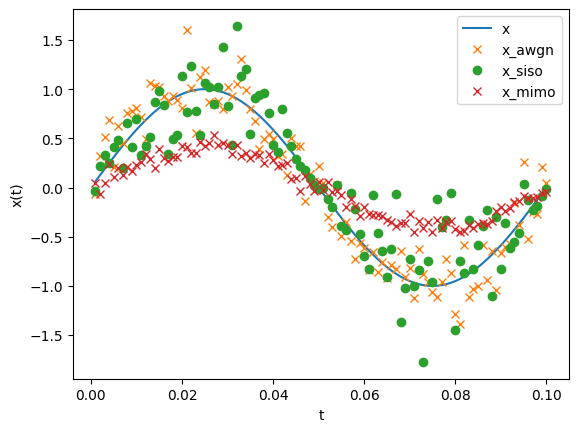

In [111]:
plt.plot(time_vector,x,'-')
plt.plot(time_vector,x_awgn,'x')
plt.plot(time_vector,x_siso,'o')
plt.plot(time_vector,x_mimo[0],'x')

plt.legend(['x','x_awgn','x_siso','x_mimo'])
plt.xlabel('t')
plt.ylabel('x(t)')
plt.show()
